In [22]:
import NNMFit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
import matplotlib.font_manager as font_manager
font_axis_label = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }
font_title = {'family': 'serif',
        'color':  'black',
        'weight': 'bold',
        'size': 20,
        }
font_legend = font_manager.FontProperties(family='serif',
                                   weight='normal',
                                   style='normal', size=13)

plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams.update({'font.family':'serif'})

In [24]:
import os
save_path  = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step1_hese_flux/muon_prior"
os.makedirs(save_path, exist_ok=True)

In [25]:
def get_1sigma(scan, parameter, bestfit_val, threshold=1.0):
    """Find where dllh crosses threshold via sign-change detection + linear interpolation."""
    scan_sorted = scan.sort_values(parameter).reset_index(drop=True)
    x = scan_sorted[parameter].values
    delta = scan_sorted["dllh"].values - threshold

    sign_changes = np.where(np.diff(np.sign(delta)))[0]
    roots = []
    for idx in sign_changes:
        x0, x1 = x[idx], x[idx + 1]
        y0, y1 = delta[idx], delta[idx + 1]
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))

    roots = np.array(roots)
    lower = roots[roots < bestfit_val]
    upper = roots[roots > bestfit_val]

    err_lo = bestfit_val - lower[-1] if len(lower) else np.nan
    err_hi = upper[0] - bestfit_val if len(upper) else np.nan
    return err_lo, err_hi

In [26]:
# new fits with updated data, muon template, bdts
fit_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_muon_prior/"    

scan_dir_dict = {
    "initial_no_prior": 
        f"{fit_path}/initial_no_prior",
    "initial_with_prior": 
        f"{fit_path}/initial_with_prior",

    "paper_no_prior": 
        f"{fit_path}/paper_no_prior",
    "paper_with_prior": 
        f"{fit_path}/paper_with_prior",
}

In [27]:
drop_unsuccessful = True
scan_dict = {}
bestfits = {}

for name, scan_dir in scan_dir_dict.items():
    scan_dict[name] = NNMFit.utilities.ScanHandler(scan_dir, dump=False, drop_unsuccessful=drop_unsuccessful)
    bestfits[name] = scan_dict[name].get_freefit(drop_unsuccessful="True")

## Best fit comparison

Which of the 4 scan configurations fits the data best? Lower llh = better fit. `dllh` is relative to the overall best fit.

In [28]:
parameter = "muongun_norm"

rows = {}
for name in scan_dir_dict:
    bf = bestfits[name]
    rows[name] = {
        "template":    name.split("_")[0],
        "prior":       "yes" if "with_prior" in name else "no",
        "muongun_norm": bf[parameter],
        "llh":          bf["llh"],
    }

df_compare = pd.DataFrame(rows).T
df_compare["dllh"] = df_compare["llh"] - df_compare["llh"].min()
df_compare = df_compare.sort_values("llh")

display(df_compare[["template", "prior", "muongun_norm", "llh", "dllh"]])

best_name = df_compare.index[0]
print(f"\nBest fit: '{best_name}'  (llh = {df_compare.loc[best_name, 'llh']:.4f})")

,template,prior,muongun_norm,llh,dllh
paper_no_prior,paper,no,2.80012,192.350456,0.0
initial_no_prior,initial,no,10.572853,192.350622,0.000166
paper_with_prior,paper,yes,1.380624,193.498583,1.148127
initial_with_prior,initial,yes,1.411442,197.289767,4.939311



Best fit: 'paper_no_prior'  (llh = 192.3505)


## Individual muongun_norm scans

$-2\Delta\log\mathcal{L}$ profile for `muongun_norm` for each of the 4 scan configurations. Red vertical = best fit; dotted verticals and shaded band = 1σ interval; dashed horizontal = threshold at 1.

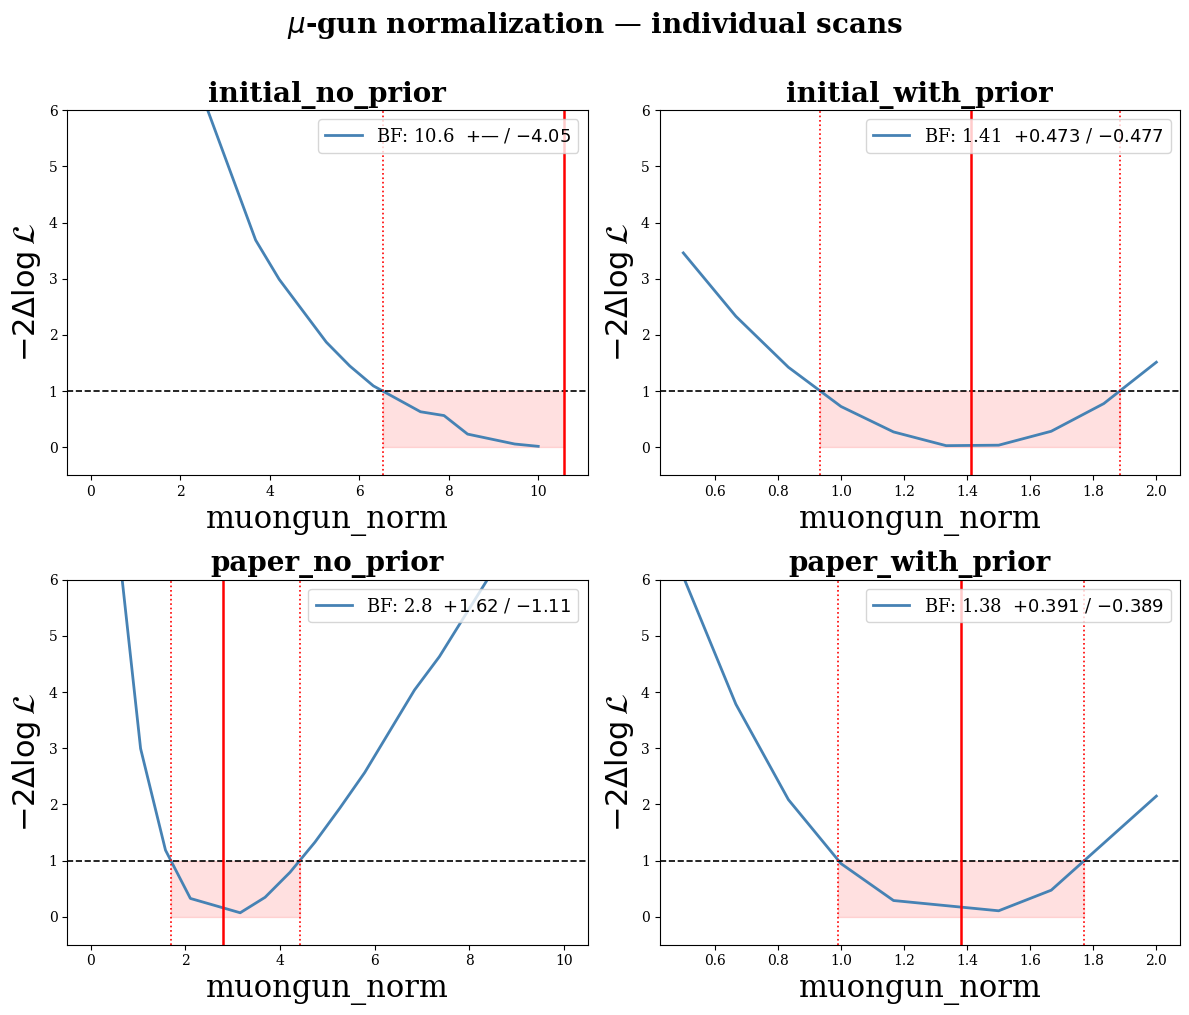

In [29]:
parameter = "muongun_norm"

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(r"$\mu$-gun normalization — individual scans", **font_title, y=1.01)
axes = axes.flatten()

for i, name in enumerate(scan_dir_dict):
    ax = axes[i]
    try:
        scan = scan_dict[name].get_scan_df(param_name=parameter, drop_unsuccessful=drop_unsuccessful)
        bestfit_val = bestfits[name][parameter]
        err_lo, err_hi = get_1sigma(scan, parameter, bestfit_val)

        scan_sorted = scan.sort_values(parameter)
        ax.plot(scan_sorted[parameter], scan_sorted["dllh"], color="steelblue", linewidth=2)
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
        ax.axvline(bestfit_val, color="red", linewidth=1.8)

        xlo = bestfit_val - err_lo if not np.isnan(err_lo) else bestfit_val
        xhi = bestfit_val + err_hi if not np.isnan(err_hi) else bestfit_val
        if not np.isnan(err_lo):
            ax.axvline(xlo, color="red", linestyle=":", linewidth=1.2)
        if not np.isnan(err_hi):
            ax.axvline(xhi, color="red", linestyle=":", linewidth=1.2)
        ax.fill_betweenx([0, 1], xlo, xhi, color="red", alpha=0.12)

        lo_str = f"{err_lo:.3g}" if not np.isnan(err_lo) else "—"
        hi_str = f"{err_hi:.3g}" if not np.isnan(err_hi) else "—"
        ax.legend([f"BF: {bestfit_val:.3g}  $+{hi_str}$ / $-{lo_str}$"],
                  prop=font_legend, loc="upper right")
    except Exception as e:
        ax.text(0.5, 0.5, f"No scan\n({e})", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(name, fontdict=font_title)
    ax.set_xlabel(parameter, fontdict=font_axis_label)
    ax.set_ylabel(r"$-2\Delta\log\mathcal{L}$", fontdict=font_axis_label)
    ax.set_ylim(-0.5, 6)

plt.tight_layout()
plt.savefig(f"{save_path}/individual_muongun_scans.png", bbox_inches="tight")
plt.show()

## Prior comparison

Overlay of with-prior vs no-prior scans for each template. Shows how the muon normalization prior shifts the best fit and tightens/shifts the constraint.

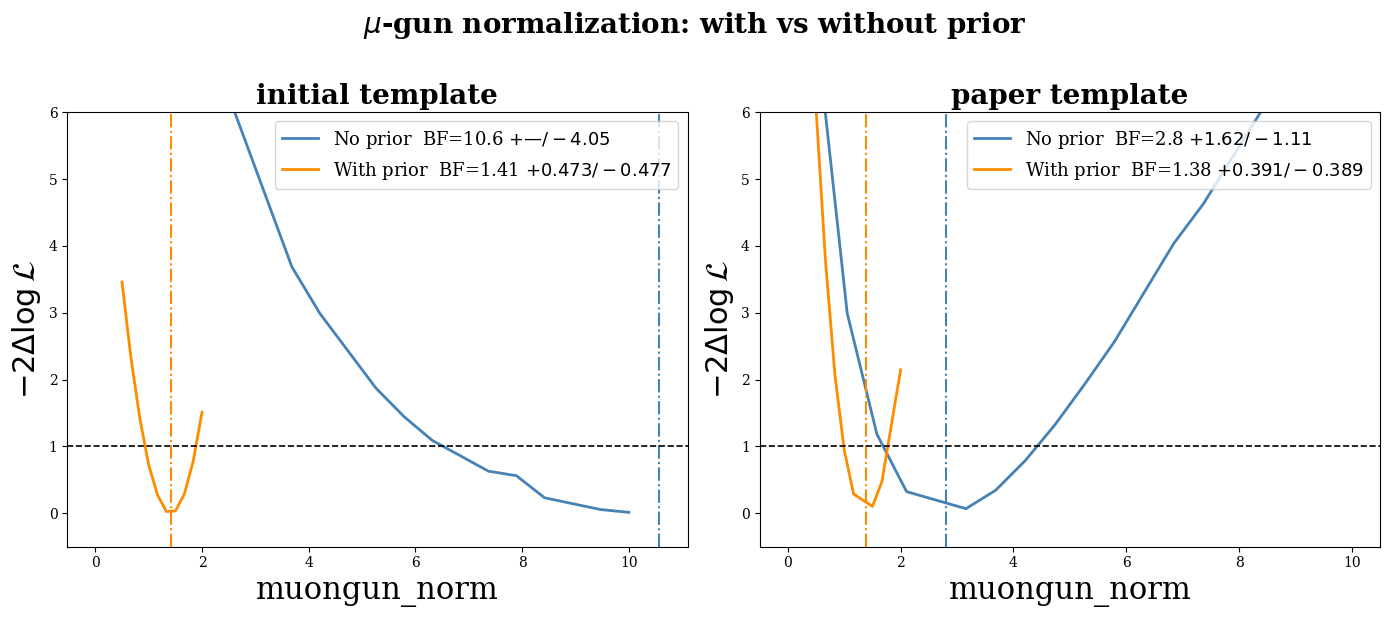

In [30]:
parameter = "muongun_norm"

templates = {
    "initial": ("initial_no_prior", "initial_with_prior"),
    "paper":   ("paper_no_prior",   "paper_with_prior"),
}

style = {
    "no_prior":   {"color": "steelblue",   "label": "No prior"},
    "with_prior": {"color": "darkorange",  "label": "With prior"},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(r"$\mu$-gun normalization: with vs without prior", **font_title, y=1.02)

for ax, (template_name, (no_prior_name, with_prior_name)) in zip(axes, templates.items()):
    for scan_name, style_key in [(no_prior_name, "no_prior"), (with_prior_name, "with_prior")]:
        s = style[style_key]
        try:
            scan = scan_dict[scan_name].get_scan_df(param_name=parameter, drop_unsuccessful=drop_unsuccessful)
            bestfit_val = bestfits[scan_name][parameter]
            err_lo, err_hi = get_1sigma(scan, parameter, bestfit_val)

            scan_sorted = scan.sort_values(parameter)
            lo_str = f"{err_lo:.3g}" if not np.isnan(err_lo) else "—"
            hi_str = f"{err_hi:.3g}" if not np.isnan(err_hi) else "—"
            legend_label = f"{s['label']}  BF={bestfit_val:.3g} $+{hi_str}/-{lo_str}$"

            ax.plot(scan_sorted[parameter], scan_sorted["dllh"],
                    color=s["color"], linewidth=2, label=legend_label)
            ax.axvline(bestfit_val, color=s["color"], linewidth=1.5, linestyle="-.")

        except Exception as e:
            ax.text(0.5, 0.5, f"{scan_name}\nerror: {e}", ha="center", va="center", transform=ax.transAxes)

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"{template_name} template", fontdict=font_title)
    ax.set_xlabel(parameter, fontdict=font_axis_label)
    ax.set_ylabel(r"$-2\Delta\log\mathcal{L}$", fontdict=font_axis_label)
    ax.set_ylim(-0.5, 6)
    ax.legend(prop=font_legend)

plt.tight_layout()
plt.savefig(f"{save_path}/prior_comparison.png", bbox_inches="tight")
plt.show()